In [2]:
import numpy as np
from numpy import linalg as LA
from  scipy.spatial.transform import Rotation as R
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
filepath = 'packet_data.npy'
data = np.load(filepath)
rot_data = []
rot_angles = []
gravity = [0, 0, 9.8]

In [4]:
t_start, t_end = int(data.shape[0]*0.5879), int(data.shape[0]*0.5888)
baro_data = data[:,10]

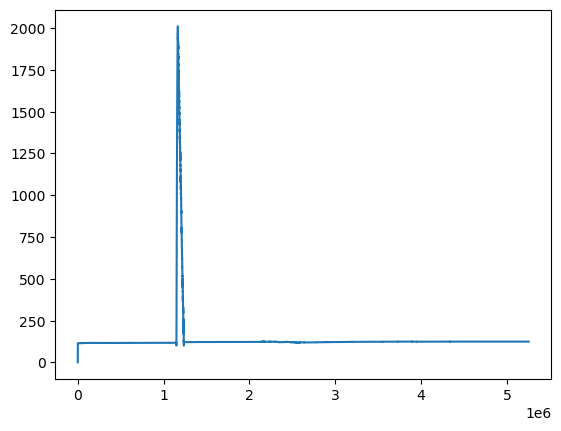

In [99]:
start = int(1e6 * 1.149)
end = int(1e6 * 1.165)

plt.plot(baro_data)

In [106]:
quaternion_data = data[:,24:28]
quaternion_data.shape
quaternion_data=quaternion_data[:,[3,0,1,2]]
quaternion_data.shape
print(quaternion_data[600000])
print(quaternion_data[500000])
print(quaternion_data[550000])


[ 0.98673397  0.16207822 -0.00848287 -0.00275119]
[ 0.98714042  0.15969431 -0.00642841 -0.00177357]
[ 9.86797571e-01  1.61773145e-01 -7.26750027e-03  2.89388863e-05]


In [ ]:
r = R.from_quat(quaternion_data)
euler_angles = r.as_euler('xyz', degrees = True)
euler_angles.shape
l2_norm = LA.norm(quaternion_data, axis = 1)
l2_norm.shape

[ 2.83109257e-04  9.99973416e-01  1.00411521e-03 -6.58339262e-03]


Text(0.5, 1.0, 'Z angle')

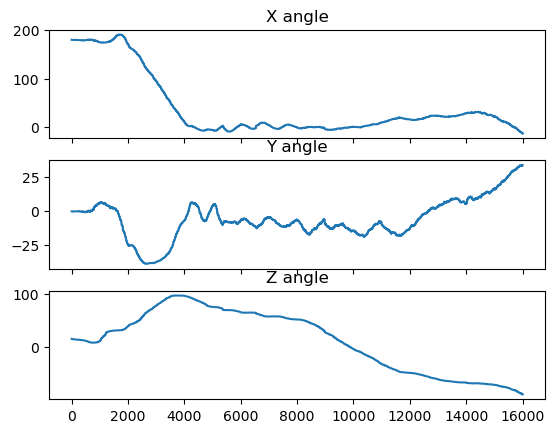

In [98]:
fig, axs = plt.subplots(3, sharex = True)

axs[0].plot(euler_angles[start:end,0])
axs[0].set_title("X angle")

axs[1].plot(euler_angles[start:end,1])
axs[1].set_title("Y angle")

axs[2].plot(euler_angles[start:end,2])
axs[2].set_title("Z angle")


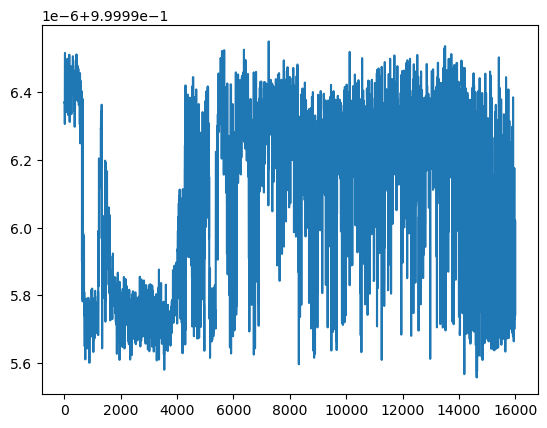

Text(0.5, 1.0, 'w')

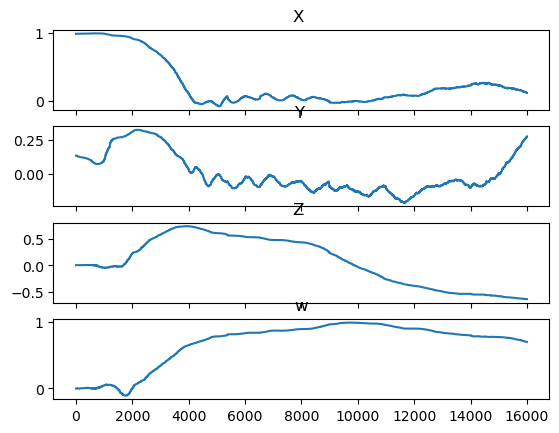

In [85]:
fig, axs = plt.subplots(4, sharex = True)

axs[0].plot(quaternion_data[start:end,0])
axs[0].set_title("X ")

axs[1].plot(quaternion_data[start:end,1])
axs[1].set_title("Y ")

axs[2].plot(quaternion_data[start:end,2])
axs[2].set_title("Z ")

axs[3].plot(quaternion_data[start:end,3])
axs[3].set_title("w")


In [113]:
bases_quaternion = [1,0,0,0]
quaternion_data_dotted = quaternion_data @ bases_quaternion
quaternion_data_dotted = np.degrees(2*(np.arccos(quaternion_data_dotted)))


In [ ]:
def quaternion_to_euler(w, x, y, z):
    # Roll (x-axis rotation)
    sinr_cosp = 2 * (w * x + y * z)
    cosr_cosp = 1 - 2 * (x**2 + y**2)
    roll = np.arctan2(sinr_cosp, cosr_cosp)

    # Pitch (y-axis rotation)
    sinp = 2 * (w * y - z * x)
    sinp = np.clip(sinp, -1.0, 1.0)  # Clip to valid range for arcsin
    pitch = np.arcsin(sinp)

    # Yaw (z-axis rotation)
    siny_cosp = 2 * (w * z + x * y)
    cosy_cosp = 1 - 2 * (y**2 + z**2)
    yaw = np.arctan2(siny_cosp, cosy_cosp)

    return roll, pitch, yaw

euler_angles = [quaternion_to_euler(w, x, y, z) for w, x, y, z in quaternion_data]
roll_angles_degrees = np.degrees([angle[0] for angle in euler_angles])
pitch_angles_degrees = np.degrees([angle[1] for angle in euler_angles])
yaw_angles_degrees = np.degrees([angle[2] for angle in euler_angles])

plt.figure(figsize=(15, 5))
plt.plot(roll_angles_degrees, marker='o', linestyle='-', color='r', label='Roll')
plt.plot(pitch_angles_degrees, marker='o', linestyle='-', color='g', label='Pitch')
plt.plot(yaw_angles_degrees, marker='o', linestyle='-', color='b', label='Yaw')
plt.title('Euler Angles During Rocket Ascent')
plt.xlabel('Time Step')
plt.ylabel('Angle (degrees)')
plt.legend()
plt.grid(True)

NameError: name 'x2' is not defined